#### FIXING RANDOMNESS FOR REPRODUCIBILITY

In [276]:
import os
import random
import numpy as np
import tensorflow as tf

# We use a fixed seed so the model trains exactly the same way every time.
# This prevents random fluctuations and ensures consistent results.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds successfully locked to:", SEED)

Random seeds successfully locked to: 42


#### PROJECT CONFIGURATION

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DATA_PATH = "../data/Gold_features.csv"

# The technical indicators and data points the model will use
FEATURE_COLUMNS = [
    "Close", "Volume", "RSI", "MACD",
    "MACD_Signal", "EMA_20", "BB_High", "BB_Low", "ATR"
]
TARGET_COLUMN = "Close"

# The model will look at the past 30 days of data to make its prediction
TIME_STEPS = 30
# We reserve 80% of the dataset for training and keep 20% hidden for testing
TRAIN_SIZE = 0.8

#### LOADING AND SPLITTING DATA

In [278]:
df = pd.read_csv(DATA_PATH)
print("Data loaded successfully. Shape:", df.shape)

# We must split the dataset into past and future BEFORE applying any scaling.
# This crucial step prevents data leakage, so the model cannot cheat by seeing the future.
split_index = int(len(df) * TRAIN_SIZE)

df_train = df.iloc[:split_index].copy()
df_test = df.iloc[split_index:].copy()

print(f"Training rows: {len(df_train)}, Testing rows: {len(df_test)}")

Data loaded successfully. Shape: (1225, 13)
Training rows: 980, Testing rows: 245


#### SCALING AND CREATING SEQUENCES

In [279]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# The scaler learns the mathematical rules only from the training data
train_features_scaled = feature_scaler.fit_transform(df_train[FEATURE_COLUMNS])
train_target_scaled = target_scaler.fit_transform(df_train[[TARGET_COLUMN]])

# We apply the previously learned rules to scale the test data
test_features_scaled = feature_scaler.transform(df_test[FEATURE_COLUMNS])
test_target_scaled = target_scaler.transform(df_test[[TARGET_COLUMN]])

def create_sequences(features, target, time_steps):
    """
    This function groups the data into rolling time windows.
    The model uses a block of previous days to predict the next single value.
    """
    X, y = [], []
    for i in range(time_steps, len(features)):
        X.append(features[i - time_steps:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features_scaled, train_target_scaled, TIME_STEPS)
X_test, y_test = create_sequences(test_features_scaled, test_target_scaled, TIME_STEPS)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (950, 30, 9)
X_test shape: (215, 30, 9)


#### BUILDING THE NEURAL NETWORK

In [280]:
model = Sequential()

# A compact LSTM layer designed to capture strong trends and ignore market noise
model.add(
    LSTM(
        units=16,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Batch Normalization acts as a shock absorber for sudden price spikes
model.add(BatchNormalization())

# Dropout randomly disables a portion of neurons during training.
# This forces the model to generalize better and prevents overfitting.
model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

C:\Users\Antek\Desktop\University\IV term\PROJ Sztuczna inteligencja\stock-price-prediction-lstm\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 16)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 32 (128.00 B)

#### TRAINING THE MODEL (WITH AUTO-SAVE)

In [281]:
os.makedirs("../data", exist_ok=True)

# The early stopping mechanism pauses training if the model stops improving.
# It also ensures the best memory weights are restored at the end.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

# The checkpoint system actively monitors the validation error.
# It automatically overwrites the file on the disk whenever a new record is achieved.
checkpoint = ModelCheckpoint(
    filepath="../data/best_gold_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# We start the training process with both safety callbacks active
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
56/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3076
Epoch 1: val_loss improved from None to 1.91996, saving model to ../data/best_gold_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2141 - val_loss: 1.9200
Epoch 2/100
55/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1110
Epoch 2: val_loss improved from 1.91996 to 1.81224, saving model to ../data/best_gold_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0923 - val_loss: 1.8122
Epoch 3/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0633
Epoch 3: val_loss improved from 1.81224 to 1.51839, saving model to ../data/best_gold_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0593 - val_loss: 1.5184
Epoch 4/100
57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0453
Epoch 4: val_loss improved from 1.51839 to 1.41509, saving model to ../data/best_gold_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0450 - val_loss: 1.4151
Epoch 5/100
52/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

#### EVALUATION AND PLOTTING RESULTS

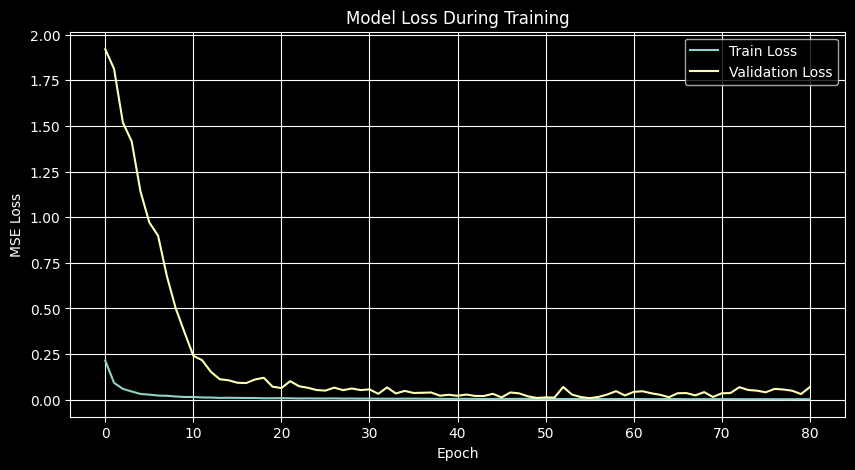

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
--- RESULTS ---
MSE: 26749.356085139392
RMSE: 163.55230382094712
MAE: 117.89191156431687 



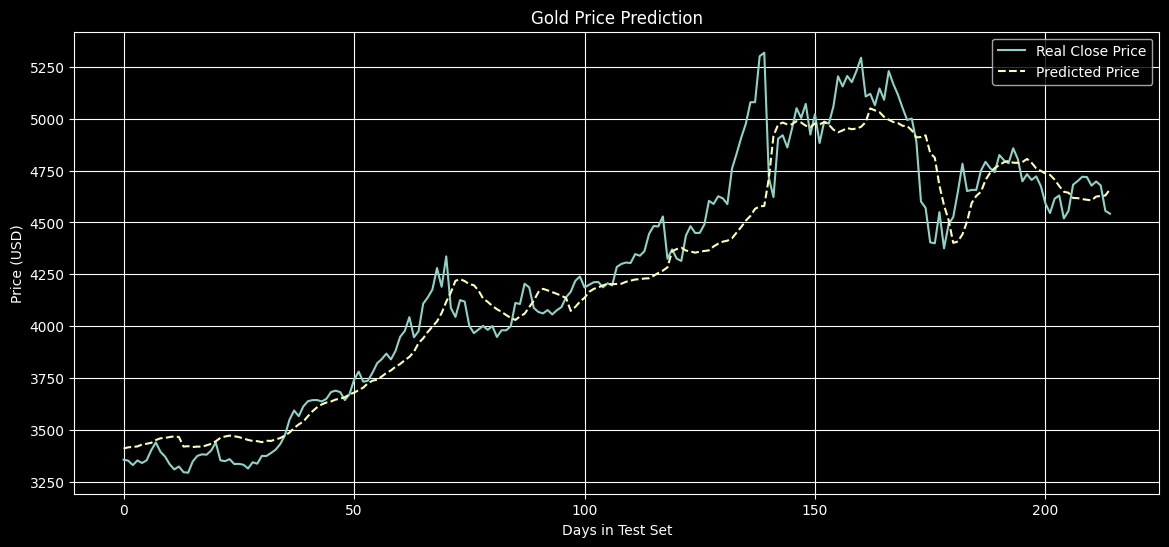

In [282]:
# Display the learning curve
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# Generate predictions based on the test dataset
y_pred_scaled = model.predict(X_test)

# Convert the scaled values back to real currency
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

# Calculate performance metrics
mse = mean_squared_error(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("--- RESULTS ---")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae, "\n")

# Display the final prediction chart
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="Real Close Price")
plt.plot(y_pred, label="Predicted Price", linestyle="--")
plt.title("Gold Price Prediction")
plt.xlabel("Days in Test Set")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### SAVING SCALERS FOR THE APPLICATION

In [283]:
os.makedirs("../data", exist_ok=True)

# The neural network brain is already saved by the ModelCheckpoint.
# Here we only export the data transformers needed by the graphic interface.
joblib.dump(feature_scaler, "../data/feature_scaler.save")
joblib.dump(target_scaler, "../data/target_scaler.save")

print("Scalers saved successfully. The system is ready for production!")

Scalers saved successfully. The system is ready for production!


#### MULTI-STEP FUTURE FORECAST (NEXT 30 DAYS)

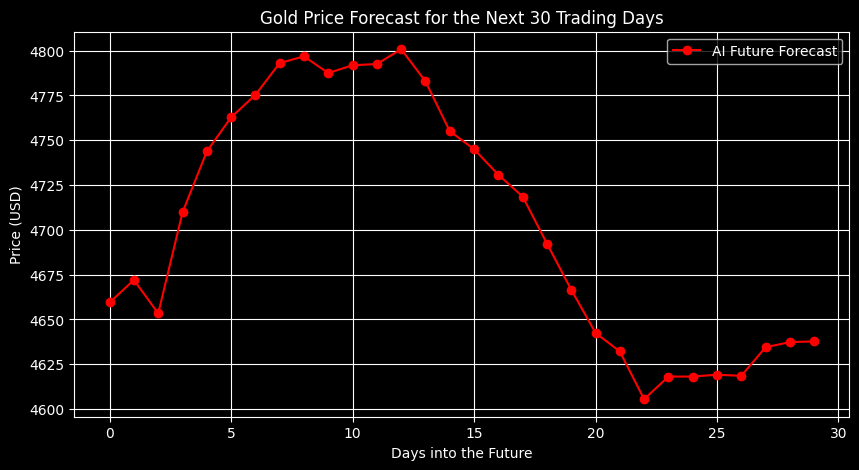

--- Future Forecast Prices ---
Day 1: $4659.48
Day 2: $4672.06
Day 3: $4653.37
Day 4: $4709.77
Day 5: $4743.76
Day 6: $4762.80
Day 7: $4775.34
Day 8: $4793.11
Day 9: $4796.84
Day 10: $4787.53
Day 11: $4791.89
Day 12: $4792.56
Day 13: $4800.82
Day 14: $4782.90
Day 15: $4755.10
Day 16: $4745.03
Day 17: $4730.79
Day 18: $4718.61
Day 19: $4692.38
Day 20: $4666.62
Day 21: $4642.55
Day 22: $4632.15
Day 23: $4605.51
Day 24: $4618.13
Day 25: $4618.18
Day 26: $4619.18
Day 27: $4618.55
Day 28: $4634.51
Day 29: $4637.38
Day 30: $4637.77


In [284]:
# We extract the final sequence from our test dataset to serve as a starting point
last_sequence = X_test[-1:].copy()

future_predictions_scaled = []

# We run an autoregressive loop to predict the upcoming month
for i in range(30):

    # Generate the prediction for the very next day
    next_day_pred_scaled = model.predict(last_sequence, verbose=0)
    future_predictions_scaled.append(next_day_pred_scaled[0, 0])

    # Slide the time window forward by dropping the oldest record
    new_sequence = np.roll(last_sequence, -1, axis=1)

    # Insert the newly predicted price into the correct feature slot
    new_sequence[0, -1, 0] = next_day_pred_scaled[0, 0]

    last_sequence = new_sequence

# Translate the forecasted sequence back to real-world prices
future_predictions_scaled = np.array(future_predictions_scaled).reshape(-1, 1)
future_predictions_usd = target_scaler.inverse_transform(future_predictions_scaled)

# Render the future trend line
plt.figure(figsize=(10, 5))
plt.plot(future_predictions_usd, label="AI Future Forecast", color="red", marker="o")
plt.title("Gold Price Forecast for the Next 30 Trading Days")
plt.xlabel("Days into the Future")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

print("--- Future Forecast Prices ---")
for day, price in enumerate(future_predictions_usd, 1):
    print(f"Day {day}: ${price[0]:.2f}")